0.6666666865348817
-2*(-1)**m/(3*2**m) + 2/3
11184811/16777216
(3253, 6747)
[1.         0.5        0.75       0.625      0.6875     0.65625
 0.671875   0.6640625  0.66796875 0.66601563 0.66699219 0.66650391
 0.66674805 0.66662598 0.66668701 0.66665649 0.66667175 0.66666412
 0.66666794 0.66666603 0.66666698 0.66666651 0.66666675 0.66666663
 0.66666669]


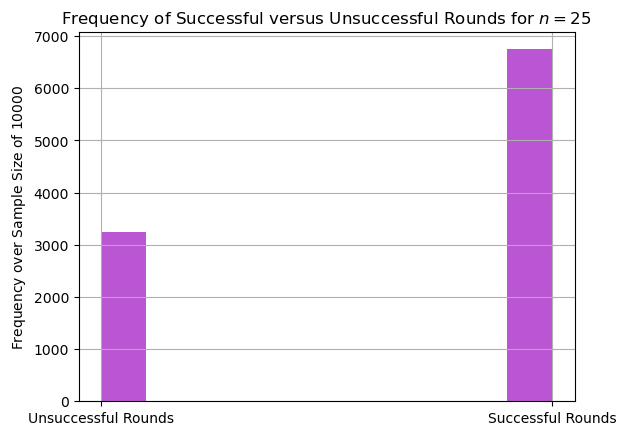

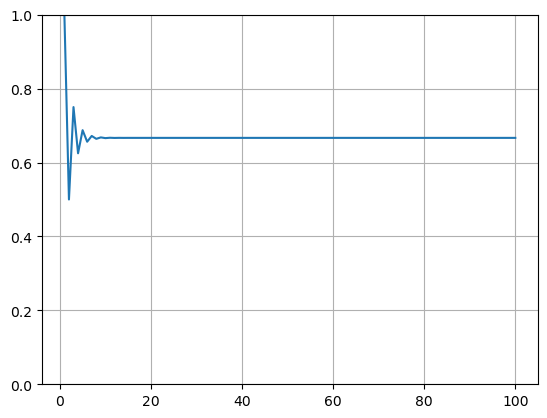

0.6666666865348816


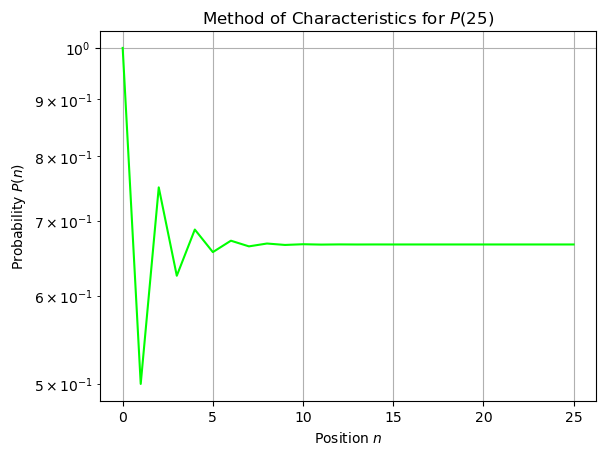

1
[1 1 1 ... 0 1 0]


In [175]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

n = 25
ntrials = 10000
begin = 1
init = [1, 0.5]

def path(m, start):
    
    num = start
    for i in range(m+1):
        
        step = np.random.randint(1,3)
        num += step
        
        if num == m:
            return 1
        elif num >= m+1:
            return 0
    
    
def test(m, start, trials):
    
    data = []
    for j in range(trials):
        pathj = path(m, start)
        data.append(int(pathj))
    
    return np.array(data)

def freq(samp):
    
    freq0 = 0
    freq1 = 0
    
    for val in samp:
        if val == 0:
            freq0 += 1
        else:
            freq1 += 1
    
    return freq0, freq1
    
A = np.array([[0.5, 0.5], [1, 0]])
lam, vec = np.linalg.eig(A)

B = np.array([[1, 1], lam])
b = np.array(init)
C = np.linalg.solve(B, b)

Pn = C[0]*(lam[0]**(n-1)) + C[1]*(lam[1]**(n-1))
print(Pn)

x, y = sp.symbols("x, y")
m = sp.symbols('m')
A2 = sp.Matrix([[sp.Rational(1, 2), sp.Rational(1, 2)], [1, 0]])
eigvals = list(A2.eigenvals().keys())
e1, e2 = eigvals[0], eigvals[1]

B2 = sp.Matrix([[1, 1], [e1, e2]])
b2 = sp.Matrix([1, sp.Rational(1, 2)])
C2 = sp.linsolve((B2, b2), x, y)

C2list = list(C2)[0]
Pnsymb = C2list[0]*(e1**(m-1)) + C2list[1]*(e2**(m-1))
print(sp.simplify(Pnsymb))
print(Pnsymb.subs(m, n))

def characteristic(num, initial):
    
    vals = initial
    for j in range(2, num+1):
        eq = 0.5*vals[j-1] + 0.5*vals[j-2]
        vals.append(eq)
        
    valsarray = np.array(vals)
    subs = np.arange(num+1)
    
    return subs, valsarray
    
def pvals(num):
    
    global B
    global b
    global C
    pjs = []
    
    for j in range(num):
        Pj = C[0]*(lam[0]**(j)) + C[1]*(lam[1]**(j))
        pjs.append(Pj)
        
    return np.array(pjs)
    
sample = test(n, begin, ntrials)
print(freq(sample))
print(pvals(n))

xvals = np.arange(1, 101)
yvals = pvals(100)

plt.hist(sample, color='mediumorchid')
plt.title(r'Frequency of Successful versus Unsuccessful Rounds for $n = 25$')
plt.xticks([0, 1], ['Unsuccessful Rounds', 'Successful Rounds'])
plt.ylabel(r'Frequency over Sample Size of $10000$')
plt.grid(True)
plt.show()

plt.plot(xvals, yvals)
plt.grid(True)
plt.ylim(0,1)
plt.show()

charx, chary = characteristic(n, init)
print(chary[n-1])
plt.semilogy(charx, chary, color='lime')
plt.grid(True)
plt.title(r'Method of Characteristics for $P(25)$')
plt.xlabel(r'Position $n$')
plt.ylabel(r'Probability $P(n)$')
plt.show()

print(path(n, begin))
print(test(n, begin, ntrials))